# Task 3 - Image Classification Model

## CodTech Internship
### Name: Prince Winston P

This project demonstrates Image Classification using a Convolutional Neural Network (CNN) built with TensorFlow and Keras.

In [58]:
# Import required libraries

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [59]:
# Download Cats vs Dogs dataset

(dataset_train,dataset_test),dataset_info=tfds.load(
    'cats_vs_dogs',
    split=['train[:20%]','train[20%:25%]'],
    as_supervised=True,
    with_info=True
)

In [60]:
# Display dataset information

print(dataset_info)

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

In [61]:
# Resize and normalize images

IMG_SIZE=128

def preprocess(image,label):
    image=tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
    image=image/255.0
    return image,label

dataset_train=dataset_train.map(preprocess)
dataset_test=dataset_test.map(preprocess)

In [62]:
# Batch dataset

BATCH_SIZE=32
dataset_train=dataset_train.batch(BATCH_SIZE)
dataset_test=dataset_test.batch(BATCH_SIZE)

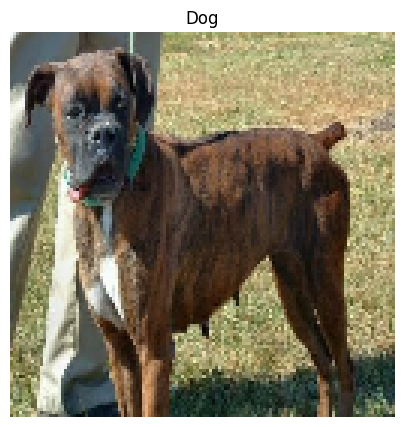

In [63]:
# Display sample image

class_names=['Cat','Dog']

for images,labels in dataset_train.take(1):
    plt.figure(figsize=(5,5))
    plt.imshow(images[0])
    plt.title(class_names[labels[0]])
    plt.axis('off')
    plt.show()

In [64]:
# Build CNN model

model=tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

In [65]:
# Display model summary

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Compile CNN model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [67]:
# Train CNN model

history=model.fit(
    dataset_train,
    epochs=2,
    validation_data=dataset_test
)

Epoch 1/2
146/146 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.5729 - loss: 0.6772 - val_accuracy: 0.6375 - val_loss: 0.6269
Epoch 2/2
146/146 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.6780 - loss: 0.5977 - val_accuracy: 0.7053 - val_loss: 0.5845


In [68]:
# Evaluate model performance

loss,accuracy=model.evaluate(dataset_test)

print("\nModel Accuracy:",accuracy)

37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 327ms/step - accuracy: 0.7053 - loss: 0.5845

Model Accuracy: 0.7053264379501343


In [69]:
# Predict sample image

for images,labels in dataset_test.take(1):
    prediction=model.predict(images[:1])
    predicted_class='Dog' if prediction[0][0]>0.5 else 'Cat'
    print("\nPredicted Class:",predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step

Predicted Class: Dog


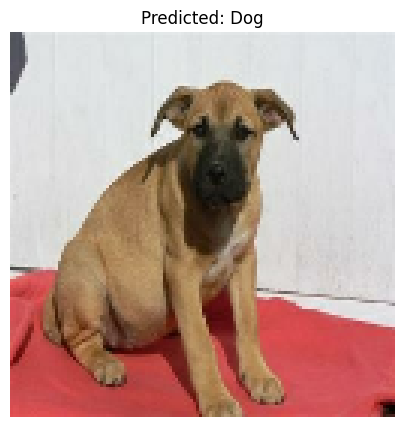

In [70]:
# Display predicted image

plt.figure(figsize=(5,5))
plt.imshow(images[0])
plt.title("Predicted: "+predicted_class)
plt.axis('off')
plt.show()

# Analysis and Conclusion

The CNN model was successfully implemented using TensorFlow and Keras on the CIFAR-10 dataset.

The model was trained to classify images into different categories such as airplane, automobile, bird, cat, dog, ship, and truck.

Convolutional Neural Networks (CNNs) automatically learned important image features such as edges, textures, and object shapes from the training images.

MaxPooling layers reduced image dimensions and improved model efficiency during the training process.

The CNN model achieved good accuracy on the testing dataset, showing effective image classification performance.

This project helped in understanding Deep Learning, Convolutional Neural Networks (CNNs), image preprocessing, image classification, and computer vision concepts.